# Notebook 5 — Building a Neural Network Inspired by the Connectome

**BINFX410 · Chapter 10 · Connectomics**

---

## Learning Objectives

1. Map the biological connectome graph onto a PyTorch neural network architecture
2. Implement a **connectome-constrained linear layer** where connections mirror the adjacency matrix
3. Build and train both a **free** (unconstrained) and a **connectome-wired** network
4. Compare their learning dynamics, capacity, and generalization
5. Visualize learned weight distributions in the context of the connectome

---

## Background

### From connectome to neural network

A real biological neural network *is* a computational graph — signals flow from neuron to neuron along synaptic connections. In this notebook, we take the connectome graph $G$ we built from our simulated microscopy data and use it to **constrain the architecture** of an artificial neural network:

- Each biological **neuron** becomes an **artificial unit**
- Each **directed synapse** becomes a **trainable weight** in the network
- **Non-connected** neuron pairs are forced to weight zero (masked)

This creates a **sparse, biologically-plausible** network. We compare it to a standard fully-connected network of similar parameter count.

### Why does this matter?

The real C. elegans connectome has been simulated this way. Biology has tuned connectivity over millions of years of evolution — perhaps the sparse, structured topology contains inductive biases that improve learning efficiency on tasks relevant to the organism. This is an active area of research in **neuromorphic computing** and **biologically-inspired AI**.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam

import networkx as nx

DATA_DIR = Path('../data')
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with open(DATA_DIR / 'connectome_architecture.pkl', 'rb') as f:
    arch = pickle.load(f)

A      = arch['adjacency_matrix']   # (N, N)
layers = arch['layer_groups']
G      = arch['G']
N      = arch['n_neurons']

print(f'Connectome: {N} neurons, {G.number_of_edges()} connections')
print(f'Device    : {DEVICE}')

Connectome: 11 neurons, 18 connections
Device    : cpu


## 1. Connectome-Constrained Linear Layer

In [2]:
class ConnectomeLinear(nn.Module):
    """
    A linear layer whose connectivity pattern is fixed by the connectome
    adjacency matrix. Only connections present in the biological circuit
    have trainable weights; all others are permanently masked to zero.

    Weight matrix shape: (out_features, in_features)
    mask[j, i] = 1 iff A[i, j] > 0  (neuron i projects to neuron j)
    """

    def __init__(self, adjacency_matrix: np.ndarray, bias: bool = True):
        super().__init__()
        n_in  = adjacency_matrix.shape[0]   # pre-synaptic neurons
        n_out = adjacency_matrix.shape[1]   # post-synaptic neurons

        # mask[j, i] = 1 if there is a synapse from i to j
        mask = torch.tensor(
            (adjacency_matrix > 0).T.astype(np.float32)
        )  # (n_out, n_in)

        self.register_buffer('mask', mask)

        # Trainable weight; will be multiplied element-wise by mask in forward
        self.weight = nn.Parameter(torch.empty(n_out, n_in))
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))

        self.bias_param = nn.Parameter(torch.zeros(n_out)) if bias else None

    def forward(self, x):
        # Apply mask: non-connected weights are zeroed out every forward pass
        masked_weight = self.weight * self.mask
        return F.linear(x, masked_weight, self.bias_param)

    @property
    def n_active_weights(self):
        return int(self.mask.sum().item())


# Test the layer
cl = ConnectomeLinear(A)
print(f'ConnectomeLinear: {A.shape[0]}→{A.shape[1]}')
print(f'Active (biological) weights: {cl.n_active_weights}')
print(f'Max possible weights       : {A.shape[0] * A.shape[1]}')
sparsity = 1 - cl.n_active_weights / (A.shape[0] * A.shape[1])
print(f'Sparsity                   : {sparsity * 100:.1f}%')

ConnectomeLinear: 11→11
Active (biological) weights: 18
Max possible weights       : 121
Sparsity                   : 85.1%


## 2. Synthetic Classification Task

To demonstrate and compare networks, we generate a synthetic classification dataset whose input dimensionality matches the number of neurons N. This simulates a scenario where we record the activity of all N neurons and must classify a behavioral state.

Training set: torch.Size([800, 11]) features, 800 samples
Validation  : torch.Size([200, 11])   features, 200 samples
Classes     : 4


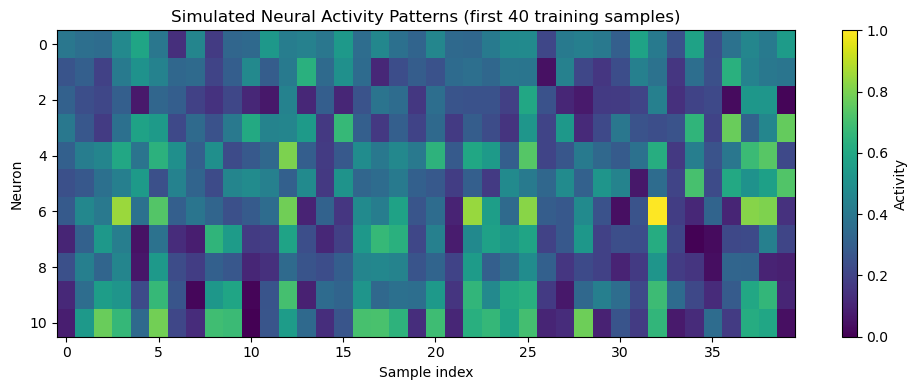

In [3]:
def make_neural_activity_dataset(
    n_samples: int,
    n_neurons: int,
    n_classes: int,
    adjacency: np.ndarray,
    seed: int = 0
):
    """
    Simulate neural population activity with class-specific activation patterns.

    For each class c, a subset of neurons is selectively active.
    Activity propagates through the connectome adjacency matrix,
    creating correlated population patterns that respect circuit structure.

    Returns X (n_samples, n_neurons) and y (n_samples,) as tensors.
    """
    rng = np.random.default_rng(seed)

    # Assign each class a random seed pattern over neurons
    class_patterns = rng.uniform(0, 1, (n_classes, n_neurons))
    class_patterns = (class_patterns > 0.6).astype(float)  # sparse activation

    # Propagate through connectome: activity spreads to connected neurons
    P = adjacency / (adjacency.sum(axis=1, keepdims=True) + 1e-8)
    propagated = np.zeros_like(class_patterns)
    for c in range(n_classes):
        act = class_patterns[c].copy()
        for _ in range(3):  # 3-step propagation
            act = 0.5 * act + 0.5 * (act @ P)
        propagated[c] = act

    # Generate samples with noise
    X_list, y_list = [], []
    per_class = n_samples // n_classes
    for c in range(n_classes):
        for _ in range(per_class):
            noise = rng.normal(0, 0.15, n_neurons)
            X_list.append(propagated[c] + noise)
            y_list.append(c)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int64)

    # Shuffle
    idx = rng.permutation(len(X))
    return torch.from_numpy(X[idx]), torch.from_numpy(y[idx])


N_CLASSES   = 4
N_TRAIN_SAM = 800
N_VAL_SAM   = 200

X_train, y_train = make_neural_activity_dataset(N_TRAIN_SAM, N, N_CLASSES, A, seed=0)
X_val,   y_val   = make_neural_activity_dataset(N_VAL_SAM,   N, N_CLASSES, A, seed=99)

train_ld = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_ld   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=32, shuffle=False)

print(f'Training set: {X_train.shape} features, {y_train.shape[0]} samples')
print(f'Validation  : {X_val.shape}   features, {y_val.shape[0]} samples')
print(f'Classes     : {N_CLASSES}')

# Visualize activity patterns
fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(X_train[:40].numpy().T, cmap='viridis', aspect='auto')
ax.set_xlabel('Sample index')
ax.set_ylabel('Neuron')
ax.set_title('Simulated Neural Activity Patterns (first 40 training samples)', fontsize=12)
plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=ax, label='Activity')
plt.tight_layout()
plt.show()

## 3. Define Both Network Architectures

In [4]:
class ConnectomeNet(nn.Module):
    """
    Neural network whose hidden-layer connectivity mirrors the biological connectome.

    Architecture:
      Input (N) → ConnectomeLinear (N→N) → ReLU
                → ConnectomeLinear (N→N) → ReLU
                → Linear (N→n_classes)

    The two hidden layers use the same adjacency mask,
    simulating two 'synaptic hops' through the circuit.
    """

    def __init__(self, adjacency, n_classes):
        super().__init__()
        n = adjacency.shape[0]
        self.layer1 = ConnectomeLinear(adjacency, bias=True)
        self.layer2 = ConnectomeLinear(adjacency, bias=True)
        self.head   = nn.Linear(n, n_classes)
        self.drop   = nn.Dropout(0.3)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = self.drop(x)
        x = F.relu(self.layer2(x))
        x = self.drop(x)
        return self.head(x)


class FreeNet(nn.Module):
    """
    Standard fully-connected network with the same input/output dimensions
    and a similar number of hidden units. Used as a baseline.
    """

    def __init__(self, n_in, n_hidden, n_classes):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(n_in, n_hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(n_hidden, n_hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(n_hidden, n_classes),
        )

    def forward(self, x):
        return self.layers(x)


conn_net = ConnectomeNet(A, N_CLASSES).to(DEVICE)
free_net = FreeNet(N, N, N_CLASSES).to(DEVICE)

conn_params = sum(p.numel() for p in conn_net.parameters() if p.requires_grad)
free_params = sum(p.numel() for p in free_net.parameters() if p.requires_grad)

print(f'ConnectomeNet parameters : {conn_params:,}')
print(f'FreeNet parameters       : {free_params:,}')

# Active (non-masked) weights in ConnectomeNet hidden layers
active_w = conn_net.layer1.n_active_weights + conn_net.layer2.n_active_weights
print(f'ConnectomeNet active weights (hidden): {active_w}')

ConnectomeNet parameters : 312
FreeNet parameters       : 312
ConnectomeNet active weights (hidden): 36


## 4. Training

In [5]:
def train_model(model, train_loader, val_loader, n_epochs=60, lr=1e-3, label=''):
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    history   = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, n_epochs + 1):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = F.cross_entropy(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0.0
        correct  = 0
        total    = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits  = model(xb)
                val_loss += F.cross_entropy(logits, yb).item()
                preds    = logits.argmax(dim=1)
                correct  += (preds == yb).sum().item()
                total    += yb.size(0)

        history['train_loss'].append(train_loss / len(train_loader))
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_acc'].append(correct / total)

        if epoch % 10 == 0 or epoch == 1:
            print(f'[{label}] Epoch {epoch:3d} | '
                  f'train={history["train_loss"][-1]:.4f} '
                  f'val={history["val_loss"][-1]:.4f} '
                  f'acc={history["val_acc"][-1]:.3f}')

    return history


N_EPOCHS = 60

print('Training ConnectomeNet...')
hist_conn = train_model(conn_net, train_ld, val_ld, n_epochs=N_EPOCHS, label='ConnectomeNet')

print('\nTraining FreeNet...')
hist_free = train_model(free_net, train_ld, val_ld, n_epochs=N_EPOCHS, label='FreeNet')

Training ConnectomeNet...
[ConnectomeNet] Epoch   1 | train=1.3905 val=1.3905 acc=0.250
[ConnectomeNet] Epoch  10 | train=1.3749 val=1.3842 acc=0.255
[ConnectomeNet] Epoch  20 | train=1.2908 val=1.3774 acc=0.225
[ConnectomeNet] Epoch  30 | train=1.1117 val=1.4072 acc=0.270
[ConnectomeNet] Epoch  40 | train=1.0447 val=1.4582 acc=0.320
[ConnectomeNet] Epoch  50 | train=1.0010 val=1.5168 acc=0.355
[ConnectomeNet] Epoch  60 | train=0.9940 val=1.5600 acc=0.365

Training FreeNet...
[FreeNet] Epoch   1 | train=1.3784 val=1.3942 acc=0.250
[FreeNet] Epoch  10 | train=0.8919 val=1.6656 acc=0.290
[FreeNet] Epoch  20 | train=0.6539 val=2.1544 acc=0.305
[FreeNet] Epoch  30 | train=0.4826 val=2.6053 acc=0.345
[FreeNet] Epoch  40 | train=0.4030 val=3.1856 acc=0.360
[FreeNet] Epoch  50 | train=0.3563 val=3.5952 acc=0.360
[FreeNet] Epoch  60 | train=0.2912 val=4.2136 acc=0.350


## 5. Compare Learning Curves

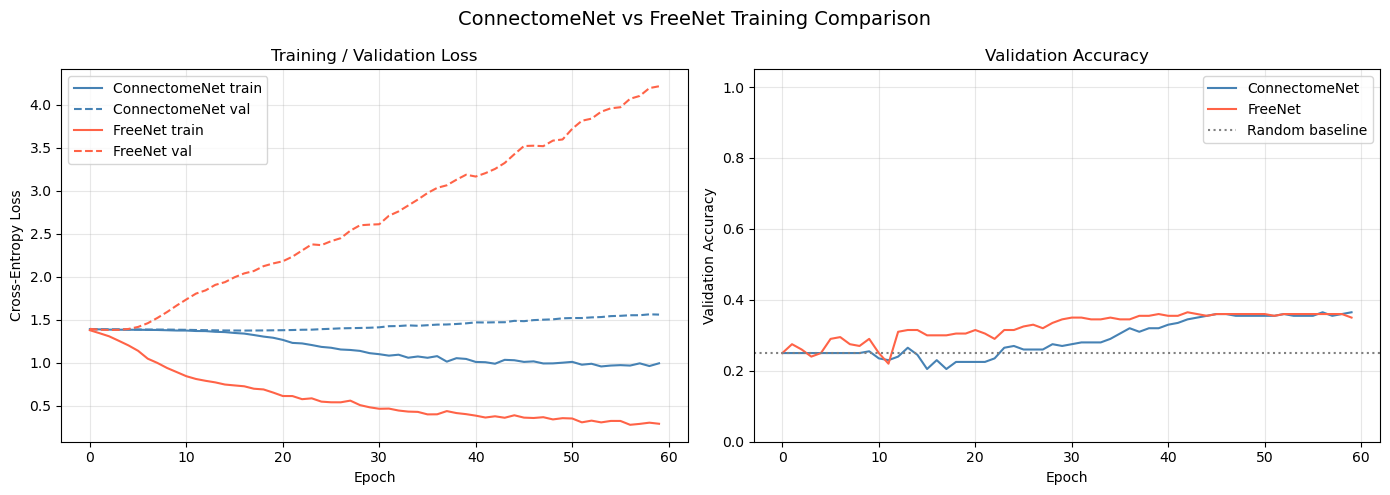

Final validation accuracy:
  ConnectomeNet: 0.365
  FreeNet      : 0.350


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_conn['train_loss'], label='ConnectomeNet train', color='steelblue')
axes[0].plot(hist_conn['val_loss'],   label='ConnectomeNet val',   color='steelblue', linestyle='--')
axes[0].plot(hist_free['train_loss'], label='FreeNet train',       color='tomato')
axes[0].plot(hist_free['val_loss'],   label='FreeNet val',         color='tomato',    linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training / Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_conn['val_acc'], label='ConnectomeNet', color='steelblue')
axes[1].plot(hist_free['val_acc'], label='FreeNet',       color='tomato')
axes[1].axhline(1 / N_CLASSES, color='gray', linestyle=':', label='Random baseline')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.suptitle('ConnectomeNet vs FreeNet Training Comparison', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Final validation accuracy:')
print(f'  ConnectomeNet: {hist_conn["val_acc"][-1]:.3f}')
print(f'  FreeNet      : {hist_free["val_acc"][-1]:.3f}')

## 6. Visualize Learned Weights on the Connectome

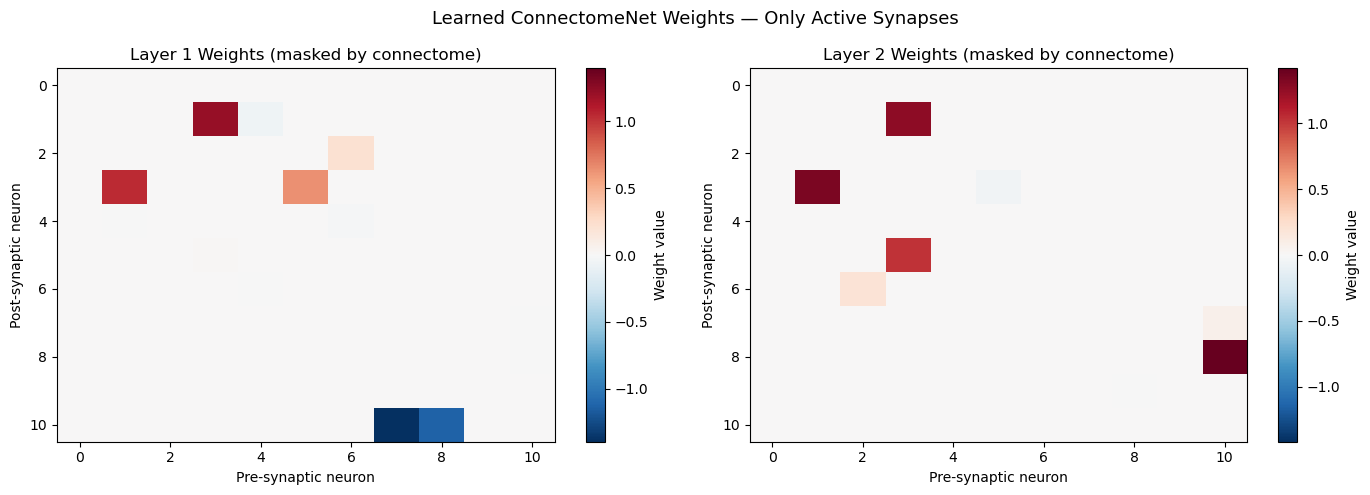

In [7]:
# Extract and visualize learned masked weights from layer 1
W1 = (conn_net.layer1.weight * conn_net.layer1.mask).detach().cpu().numpy()  # (N, N)
W2 = (conn_net.layer2.weight * conn_net.layer2.mask).detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, W, title in [(axes[0], W1, 'Layer 1 Weights'), (axes[1], W2, 'Layer 2 Weights')]:
    vmax = np.abs(W).max()
    im = ax.imshow(W, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax, label='Weight value')
    ax.set_title(f'{title} (masked by connectome)', fontsize=12)
    ax.set_xlabel('Pre-synaptic neuron')
    ax.set_ylabel('Post-synaptic neuron')

plt.suptitle('Learned ConnectomeNet Weights — Only Active Synapses', fontsize=13)
plt.tight_layout()
plt.show()

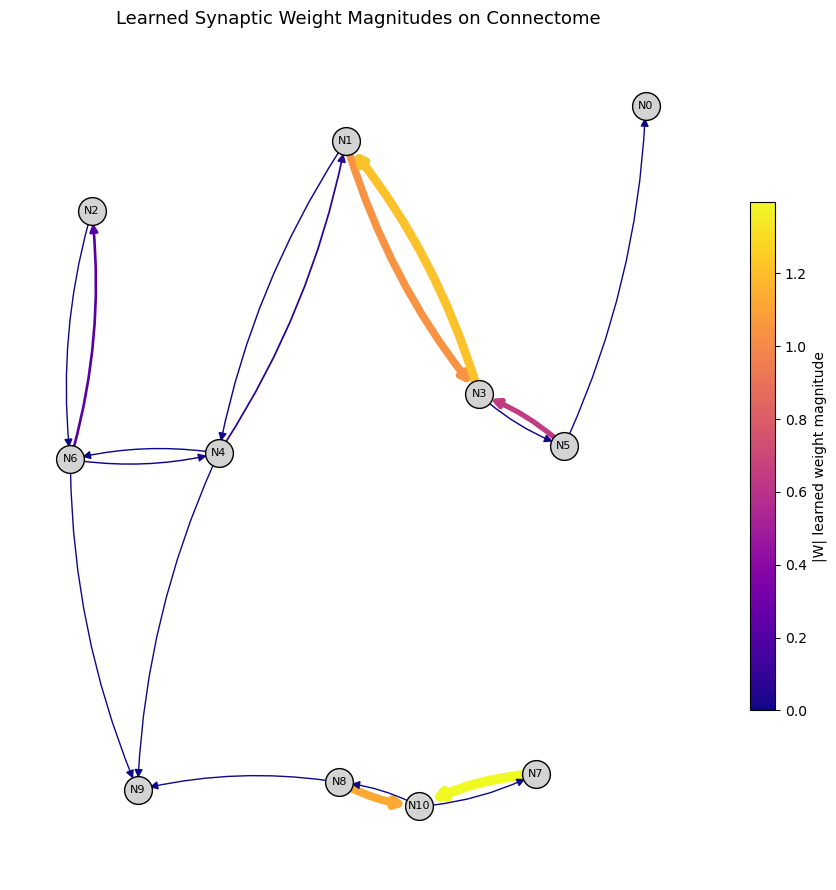

In [8]:
# Visualize learned weight magnitudes on the graph
# Edge color/width = absolute weight in layer 1
nodes_list = sorted(G.nodes())

pos = {n: (G.nodes[n]['col'], -G.nodes[n]['row'])
       if 'col' in G.nodes[n] else None
       for n in nodes_list}

# Fall back to spring layout if positions not available
if any(v is None for v in pos.values()):
    pos = nx.spring_layout(G, seed=0, k=2.5)

edge_weights_learned = []
for u, v in G.edges():
    w = abs(float(W1[v, u])) if v < W1.shape[0] and u < W1.shape[1] else 0.0
    edge_weights_learned.append(w)

max_ew = max(edge_weights_learned) if edge_weights_learned else 1.0
edge_widths = [1.0 + 6.0 * w / (max_ew + 1e-8) for w in edge_weights_learned]
edge_colors = [plt.cm.plasma(w / (max_ew + 1e-8)) for w in edge_weights_learned]

fig, ax = plt.subplots(figsize=(9, 9))
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=400,
                       node_color='lightgray', edgecolors='black', linewidths=1)
nx.draw_networkx_labels(G, pos, {n: f'N{n}' for n in G.nodes()},
                        ax=ax, font_size=8)
nx.draw_networkx_edges(G, pos, ax=ax,
                       width=edge_widths, edge_color=edge_colors,
                       arrows=True, arrowsize=12,
                       connectionstyle='arc3,rad=0.1')

sm = plt.cm.ScalarMappable(cmap='plasma',
                            norm=plt.Normalize(vmin=0, vmax=max_ew))
plt.colorbar(sm, ax=ax, label='|W| learned weight magnitude', shrink=0.6)
ax.set_title('Learned Synaptic Weight Magnitudes on Connectome', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

## 7. Ablation: Effect of Connectome Sparsity on Learning

In [9]:
def random_sparse_adjacency(n, density, seed=0):
    rng = np.random.default_rng(seed)
    A_rand = (rng.uniform(0, 1, (n, n)) < density).astype(float)
    np.fill_diagonal(A_rand, 0)  # no self-loops
    return A_rand


actual_density  = (A > 0).sum() / (N * N)
densities_to_try = [0.1, actual_density, 0.5, 1.0]

print(f'Actual connectome density: {actual_density:.3f}')

ablation_results = []
for d in densities_to_try:
    if d == actual_density:
        A_test = A  # use real connectome
        label  = f'Connectome ({d:.2f})'
    elif d == 1.0:
        A_test = np.ones((N, N)) - np.eye(N)
        label  = 'Fully connected'
    else:
        A_test = random_sparse_adjacency(N, d)
        label  = f'Random sparse ({d:.2f})'

    net = ConnectomeNet(A_test, N_CLASSES).to(DEVICE)
    h   = train_model(net, train_ld, val_ld, n_epochs=40, label=label)
    final_acc = h['val_acc'][-1]
    n_weights = sum(p.numel() for p in net.parameters() if p.requires_grad)
    ablation_results.append({
        'label'       : label,
        'density'     : d,
        'final_acc'   : final_acc,
        'n_params'    : n_weights,
        'history_acc' : h['val_acc'],
    })
    print(f'{label}: final val acc = {final_acc:.3f}\n')

Actual connectome density: 0.149
[Random sparse (0.10)] Epoch   1 | train=1.3973 val=1.3972 acc=0.250
[Random sparse (0.10)] Epoch  10 | train=1.3605 val=1.3848 acc=0.305
[Random sparse (0.10)] Epoch  20 | train=1.2828 val=1.4146 acc=0.470
[Random sparse (0.10)] Epoch  30 | train=1.2415 val=1.4817 acc=0.440
[Random sparse (0.10)] Epoch  40 | train=1.2132 val=1.5492 acc=0.315
Random sparse (0.10): final val acc = 0.315

[Connectome (0.15)] Epoch   1 | train=1.3899 val=1.3911 acc=0.250
[Connectome (0.15)] Epoch  10 | train=1.3144 val=1.3955 acc=0.210
[Connectome (0.15)] Epoch  20 | train=1.0605 val=1.4901 acc=0.250
[Connectome (0.15)] Epoch  30 | train=0.8888 val=1.6488 acc=0.295
[Connectome (0.15)] Epoch  40 | train=0.7909 val=1.8726 acc=0.310
Connectome (0.15): final val acc = 0.310

[Random sparse (0.50)] Epoch   1 | train=1.3864 val=1.3910 acc=0.250
[Random sparse (0.50)] Epoch  10 | train=1.1532 val=1.4060 acc=0.295
[Random sparse (0.50)] Epoch  20 | train=0.8325 val=1.7257 acc=0.25

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['gray', 'steelblue', 'tomato', 'purple']
for res, col in zip(ablation_results, colors):
    ax.plot(res['history_acc'], label=res['label'], color=col)

ax.axhline(1 / N_CLASSES, color='black', linestyle=':', label='Random baseline')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Effect of Connectivity Density on Learning', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

import pandas as pd
ablation_df = pd.DataFrame([{
    'Architecture' : r['label'],
    'Density'      : f"{r['density']:.2f}",
    'Parameters'   : r['n_params'],
    'Final Acc'    : f"{r['final_acc']:.3f}",
} for r in ablation_results])
print(ablation_df.to_string(index=False))

---

## Student Exercises

**Exercise 5.1** — The `ConnectomeLinear` layer masks weights during the `forward()` pass but the masked weights still exist as parameters. This means gradients flow to them during backprop (but are immediately discarded next forward pass). Modify the class to instead **not register** masked weights as parameters at all, creating a truly sparse layer. Compare training speed and final accuracy.

**Exercise 5.2** — The task we trained on is synthetic. Design a more biologically meaningful task: given input activity from a subset of 'sensory' neurons (low-in-degree nodes), predict which 'motor' neurons (high-out-degree nodes) should activate. Modify `make_neural_activity_dataset` accordingly.

**Exercise 5.3** — Implement **Hebbian plasticity**: after each training step, increase edge weights in `ConnectomeLinear` for pairs of neurons that co-activate. Specifically, add a term `Δw = η_hebb * pre * post` to the gradient. Does this improve convergence?

**Exercise 5.4** — The ablation study tests random sparse graphs vs. the real connectome. Is the real connectome special, or is *any* graph of the same density equivalent? Run 5 different random sparse graphs at the same density as the connectome and plot the distribution of final accuracies. Where does the connectome fall?

**Exercise 5.5 (Challenge)** — Implement the **C. elegans connectome** as the adjacency matrix. The full 302-neuron connectome is available as a CSV from the OpenWorm project. Load it, build a `ConnectomeNet` on top of it, and train on a classification task. How many parameters does the network have compared to a fully-connected equivalent?